# Gradient-Based Poisoning em VQC

Este notebook implementa um ataque de poisoning de classificação em um VQC.
A ideia do laço externo é mover pontos contaminados para regiões que aumentam a perda de validação do modelo treinado com esses pontos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms import VQC
from qiskit.primitives import StatevectorSampler

np.random.seed(7)

In [3]:
X, y = make_moons(n_samples=160, noise=0.18, random_state=7)

X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=7,
 )

X_fit_raw, X_val_raw, y_fit, y_val = train_test_split(
    X_train_raw,
    y_train_raw,
    test_size=0.3,
    stratify=y_train_raw,
    random_state=7,
 )

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_fit = scaler.fit_transform(X_fit_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print('Shapes:', X_fit.shape, X_val.shape, X_test.shape)
print('Train labels:', np.bincount(y_fit))
print('Val labels:', np.bincount(y_val))
print('Test labels:', np.bincount(y_test))

Shapes: (84, 2) (36, 2) (40, 2)
Train labels: [42 42]
Val labels: [18 18]
Test labels: [20 20]


In [4]:
def create_vqc(maxiter=40):
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
    ansatz = RealAmplitudes(num_qubits=2, reps=1)
    optimizer = COBYLA(maxiter=maxiter)
    sampler = StatevectorSampler()
    return VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        sampler=sampler,
    )


def train_vqc(X_train_local, y_train_local, maxiter=40):
    model = create_vqc(maxiter=maxiter)
    model.fit(X_train_local, y_train_local)
    return model


def cross_entropy_on_dataset(model, X_eval, y_eval):
    if hasattr(model, 'predict_proba'):
        proba = np.asarray(model.predict_proba(X_eval))
        proba = np.clip(proba, 1e-9, 1.0 - 1e-9)
        return float(log_loss(y_eval, proba, labels=[0, 1]))
    predictions = np.asarray(model.predict(X_eval))
    return float(1.0 - accuracy_score(y_eval, predictions))


def classification_accuracy(model, X_eval, y_eval):
    predictions = np.asarray(model.predict(X_eval))
    return float(accuracy_score(y_eval, predictions))


clean_model = train_vqc(X_fit, y_fit, maxiter=40)
clean_val_loss = cross_entropy_on_dataset(clean_model, X_val, y_val)
clean_test_acc = classification_accuracy(clean_model, X_test, y_test)
clean_test_loss = cross_entropy_on_dataset(clean_model, X_test, y_test)

print(f'Clean validation loss: {clean_val_loss:.4f}')
print(f'Clean test accuracy:   {clean_test_acc:.4f}')
print(f'Clean test loss:       {clean_test_loss:.4f}')

C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072\335144955.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072\335144955.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=1)
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Clean validation loss: 0.9312
Clean test accuracy:   0.5500
Clean test loss:       0.8670


In [5]:
source_class = 0
target_class = 1
poison_count = 2
outer_steps = 3
finite_diff_eps = 0.03
poison_lr = 0.3

source_indices = np.where(y_fit == source_class)[0]
rng = np.random.default_rng(7)
poison_indices = rng.choice(source_indices, size=poison_count, replace=False)

X_base = np.delete(X_fit, poison_indices, axis=0)
y_base = np.delete(y_fit, poison_indices, axis=0)
X_poison = X_fit[poison_indices].copy()
y_poison = np.full(poison_count, target_class, dtype=int)

print('Poison indices:', poison_indices)
print('Initial poison points:')
print(X_poison)

def poisoned_dataset(X_poison_candidate):
    X_train_poisoned = np.vstack([X_base, X_poison_candidate])
    y_train_poisoned = np.concatenate([y_base, y_poison])
    return X_train_poisoned, y_train_poisoned


def attack_objective(X_poison_candidate):
    X_train_poisoned, y_train_poisoned = poisoned_dataset(X_poison_candidate)
    model = train_vqc(X_train_poisoned, y_train_poisoned, maxiter=20)
    return cross_entropy_on_dataset(model, X_val, y_val), model


def finite_difference_gradient(X_poison_candidate):
    gradient = np.zeros_like(X_poison_candidate)
    base_loss, _ = attack_objective(X_poison_candidate)
    for row in range(X_poison_candidate.shape[0]):
        for col in range(X_poison_candidate.shape[1]):
            plus = X_poison_candidate.copy()
            minus = X_poison_candidate.copy()
            plus[row, col] = np.clip(plus[row, col] + finite_diff_eps, 0.0, np.pi)
            minus[row, col] = np.clip(minus[row, col] - finite_diff_eps, 0.0, np.pi)
            loss_plus, _ = attack_objective(plus)
            loss_minus, _ = attack_objective(minus)
            gradient[row, col] = (loss_plus - loss_minus) / (2.0 * finite_diff_eps)
    return base_loss, gradient


history = []
for step in range(outer_steps):
    loss_value, gradient = finite_difference_gradient(X_poison)
    X_poison = np.clip(X_poison + poison_lr * gradient, 0.0, np.pi)
    poisoned_loss, poisoned_model = attack_objective(X_poison)
    history.append((step + 1, poisoned_loss, np.linalg.norm(gradient)))
    print(f'Step {step + 1}: validation loss = {poisoned_loss:.4f}, gradient norm = {np.linalg.norm(gradient):.4f}')

final_poisoned_X, final_poisoned_y = poisoned_dataset(X_poison)
poisoned_model = train_vqc(final_poisoned_X, final_poisoned_y, maxiter=40)
poisoned_test_acc = classification_accuracy(poisoned_model, X_test, y_test)
poisoned_test_loss = cross_entropy_on_dataset(poisoned_model, X_test, y_test)
poisoned_val_loss = cross_entropy_on_dataset(poisoned_model, X_val, y_val)

print(f'Poisoned validation loss: {poisoned_val_loss:.4f}')
print(f'Poisoned test accuracy:   {poisoned_test_acc:.4f}')
print(f'Poisoned test loss:       {poisoned_test_loss:.4f}')

# ASR proxy: sem gatilho escalar fixo; usa-se a media dos pontos de poison otimizados
# como padrao aplicado a amostras de teste com rotulo != classe-alvo (mesma logica
# dos notebooks com trigger explicito).
trigger_proxy = np.mean(X_poison, axis=0)
mask_asr = y_test != target_class
n_asr = int(np.sum(mask_asr))
if n_asr > 0:
    X_asr = np.tile(trigger_proxy, (n_asr, 1))
    pred_asr_clean = np.asarray(clean_model.predict(X_asr))
    pred_asr_poisoned = np.asarray(poisoned_model.predict(X_asr))
    asr_limpa = float(np.mean(pred_asr_clean == target_class))
    asr_contaminada = float(np.mean(pred_asr_poisoned == target_class))
else:
    asr_limpa = float('nan')
    asr_contaminada = float('nan')

print(f'ASR limpa (modelo limpo + padrao poison):        {asr_limpa:.4f}')
print(f'ASR contaminada (modelo poison + padrao poison):   {asr_contaminada:.4f}')

C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072\335144955.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072\335144955.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=1)
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Poison indices: [77 50]
Initial poison points:
[[0.22805616 1.2172744 ]
 [0.43185325 1.85378607]]


C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072\335144955.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072\335144955.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=1)
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072

Step 1: validation loss = 0.8194, gradient norm = 2.5934


C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072\335144955.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072\335144955.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=1)
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072

Step 2: validation loss = 0.9444, gradient norm = 3.0199


C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072\335144955.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072\335144955.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=1)
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_25072

Step 3: validation loss = 0.8858, gradient norm = 1.5461
Poisoned validation loss: 0.9315
Poisoned test accuracy:   0.5000
Poisoned test loss:       0.8708


Clean vs poisoned comparison:
Clean test accuracy:    0.5500
Poisoned test accuracy: 0.5000
Accuracy drop:          0.0500


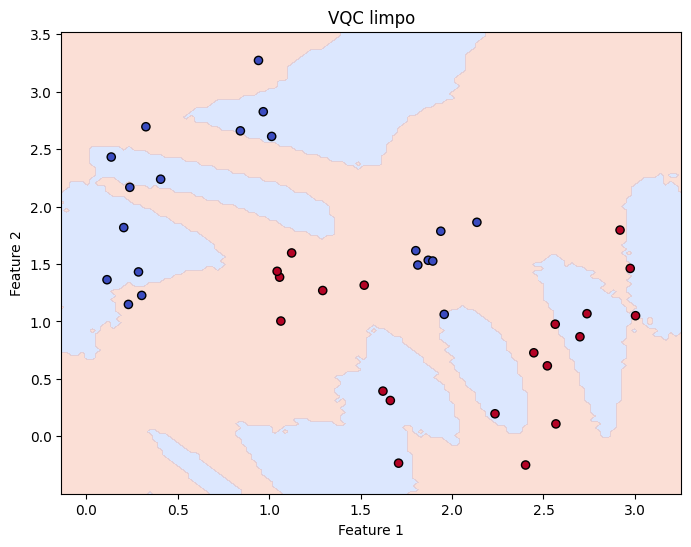

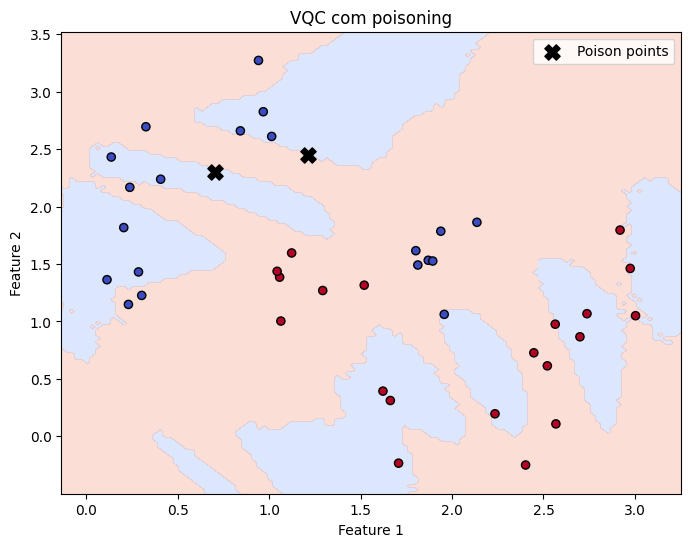

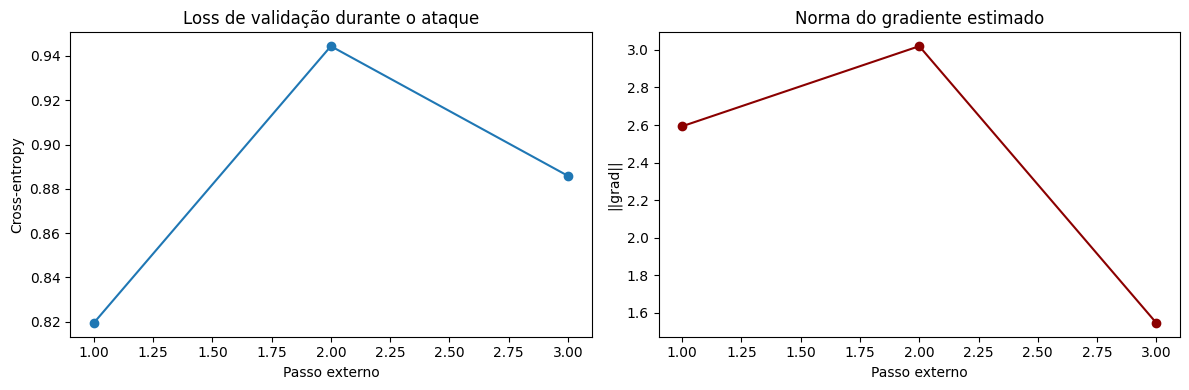

In [6]:
def plot_decision_boundary(model, X_reference, y_reference, title, poisoned_points=None):
    x_min, x_max = X_reference[:, 0].min() - 0.25, X_reference[:, 0].max() + 0.25
    y_min, y_max = X_reference[:, 1].min() - 0.25, X_reference[:, 1].max() + 0.25
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, 120),
        np.linspace(y_min, y_max, 120),
    )
    grid = np.c_[grid_x.ravel(), grid_y.ravel()]
    grid_pred = np.asarray(model.predict(grid)).reshape(grid_x.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(grid_x, grid_y, grid_pred, alpha=0.3, levels=[-0.5, 0.5, 1.5], cmap='coolwarm')
    plt.scatter(X_reference[:, 0], X_reference[:, 1], c=y_reference, cmap='coolwarm', edgecolor='k', s=35)
    if poisoned_points is not None:
        plt.scatter(poisoned_points[:, 0], poisoned_points[:, 1], c='black', marker='X', s=120, label='Poison points')
        plt.legend(loc='upper right')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()


print('Clean vs poisoned comparison:')
print(f'Clean test accuracy:    {clean_test_acc:.4f}')
print(f'Poisoned test accuracy: {poisoned_test_acc:.4f}')
print(f'Accuracy drop:          {clean_test_acc - poisoned_test_acc:.4f}')
print(f'ASR limpa:              {asr_limpa:.4f}')
print(f'ASR contaminada:       {asr_contaminada:.4f}')


plot_decision_boundary(clean_model, X_test, y_test, 'VQC limpo')
plot_decision_boundary(poisoned_model, X_test, y_test, 'VQC com poisoning', poisoned_points=X_poison)


if history:
    steps, losses, norms = zip(*history)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(steps, losses, marker='o')
    ax[0].set_title('Loss de validação durante o ataque')
    ax[0].set_xlabel('Passo externo')
    ax[0].set_ylabel('Cross-entropy')
    ax[1].plot(steps, norms, marker='o', color='darkred')
    ax[1].set_title('Norma do gradiente estimado')
    ax[1].set_xlabel('Passo externo')
    ax[1].set_ylabel('||grad||')
    plt.tight_layout()
    plt.show()